# Transformer Implementation (cross attention)

In this notebook, we will implement the Transformer architecture.\
Starting point: https://nlp.seas.harvard.edu/annotated-transformer/

$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$

In [1]:
import copy
import time
import math

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from torch.optim.lr_scheduler import LambdaLR
from torch.nn.functional import pad, log_softmax
from torch.utils.data import DataLoader

In [2]:
DATA_PATH = "kaggle/input/wmt-2014-english-french/wmt14_translate_fr-en_train.csv"
DEVICE = "mps"

CONFIG = {
    "batch_size": 16,
    "d_model": 512,
    "vocab_size": 32000,
    "dataset_lenght": 100000,  # Lines of the CSV dataset
    "num_epochs": 3,
    "accum_iter": 10,  # Amount of batches computed before incrementing the weights
    "base_lr": 1.0,  # Learning rate
    "max_padding": 72,
    "warmup": 3000  # Linear increase of the learning rate
}

In [3]:
class EncoderDecoder(nn.Module):
    "A standard Encoder-Decoder architecture."

    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        # src: (N, L)
        # tgt: (N, L)
        # src_mask: (N, 1, L)
        # tgt_mask: (N, 1, L, L)
        "Take in and process masked src and target sequences."
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

In [4]:
class Generator(nn.Module):
    "Define standard linear + softmax generation step. Final step."

    def __init__(self, d_model, vocab):
        super().__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        # x: (N, L, D)
        # output: (N, L, V)
        probability = log_softmax(self.proj(x), dim=-1)
        return probability

In [5]:
def clones(module, N):
    "Helper to produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [6]:
class Encoder(nn.Module):
    "Core encoder is a stack of N layers"

    def __init__(self, layer, N):
        super().__init__()
        self.layers = clones(layer, N)
        self.norm = RMSNorm(layer.feature_amount)

    def forward(self, x, mask):
        # x: (N, L, D)
        # mask: (N, 1, L)
        # output: (N, L, D)
        "Pass the input (and mask) through each layer in turn."
        for layer in self.layers:
            x = layer(x, mask)
            # There's one normalization per encoder layer
        return self.norm(x)

In [7]:
class LayerNorm(nn.Module):
    "Construct a layernorm module."

    def __init__(self, feature_amount, eps=1e-6):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(feature_amount))
        self.offset = nn.Parameter(torch.zeros(feature_amount))
        self.eps = eps  # To not divide by zero

    def forward(self, x):
        # x: (N, L, D)
        # output: (N, L, D)
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.scale * (x - mean) / (std + self.eps) + self.offset

In [8]:
class RMSNorm(nn.Module):
    "Only scale by root mean square. Computationaly more efficient. Doesn't hurt performance."

    def __init__(self, river_size, eps=1e-6):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(river_size))
        self.eps = eps

    def forward(self, x):
        # x: (B, L, S*D)
        rms = torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return self.scale * (x / rms)

In [9]:
class ResidualConnection(nn.Module):
    """
    A residual connection followed by a layer norm.
    Note for code simplicity the norm is first as opposed to last.
    """

    def __init__(self, feature_amount, dropout_rate):
        super().__init__()
        self.norm = RMSNorm(feature_amount)
        self.dropout = nn.Dropout(dropout_rate) 
        # Zeros randomly a part of the weights during training (not inference)

    def forward(self, x, sublayer):
        # x: (N, L, D)
        # sublayer: function (N, L, D) -> (N, L, D)
        # output: (N, L, D)
        "Apply residual connection to any sublayer with the same size."
        return x + self.dropout(sublayer(self.norm(x)))

In [10]:
class EncoderLayer(nn.Module):
    "Encoder is made up of self-attention and feed forward"

    def __init__(self, feature_amount, self_attn, feed_forward, dropout_rate):
        super().__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(ResidualConnection(feature_amount, dropout_rate), 2)
        self.feature_amount = feature_amount

    def forward(self, x, mask):
        # x: (N, L, D)
        # mask: (N, 1, L)
        # output: (N, L, D)
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        x = self.sublayer[1](x, self.feed_forward)
        return x

In [11]:
class Decoder(nn.Module):
    "Generic N layer decoder with masking."

    def __init__(self, layer, N):
        super().__init__()
        self.layers = clones(layer, N)
        self.norm = RMSNorm(layer.feature_amount)

    def forward(self, x, memory, src_mask, tgt_mask):
        # x: (N, L, D)
        # memory: (N, L_src, D)
        # src_mask: (N, 1, L_src)
        # tgt_mask: (N, 1, L, L)
        # output: (N, L, D)
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

In [12]:
class DecoderLayer(nn.Module):
    "Decoder is made of 3 layers: self-attention, source-attention, and feed forward"

    def __init__(self, feature_amount, self_attn, src_attn, feed_forward, dropout_rate):
        super().__init__()
        self.feature_amount = feature_amount
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(ResidualConnection(feature_amount, dropout_rate), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        # x: (N, L, D)
        # memory: (N, L_src, D)
        # src_mask: (N, 1, L_src)
        # tgt_mask: (N, 1, L, L)
        # output: (N, L, D)
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        x = self.sublayer[2](x, self.feed_forward)
        return x

In [13]:
def subsequent_mask(sentence_length):
    "Mask out subsequent positions."

    attn_shape = (1, sentence_length, sentence_length)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1)
    # Zeros everything under the first line above the diagonal of the matrix
    mask = (subsequent_mask == 0) # True/False instead of 0/1
    return mask


In [14]:
def attention(query, key, value, mask=None, dropout=None):
    "Compute Scaled Dot Product Attention"

    d_k = query.size(-1)  # Query/key smaller space dimension (divider of d_model)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    # Divide by sqrt(d_k) to not reach softmax plateau where gradient is close to 0

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
        
    p_attn = scores.softmax(dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)

    return torch.matmul(p_attn, value), p_attn

In [15]:
class MultiHeadedAttention(nn.Module):
    """
    Multi-head attention module: projects into smaller dimension spaces 
    and then apply specialized attention in each of them
    """

    def __init__(self, head_amount, d_model, dropout_rate=0.1):
        "Take in model size and number of heads."
        super().__init__()
        assert d_model % head_amount == 0
        self.d_k = d_model // head_amount # d_model = head_amount * d_k
        self.head_amount = head_amount
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, query, key, value, mask=None):
        # query, key, value: (N, L, D)
        # mask: (N, 1, L)
        # output: (N, L, D)
        if mask is not None:
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)

        # 1) Do all the linear projections in batch from d_model => h x d_k
        query, key, value = [
            lin(x).view(nbatches, -1, self.head_amount, self.d_k).transpose(1, 2)
            for lin, x in zip(self.linears, (query, key, value))
        ]

        # 2) Apply attention on all the projected vectors in batch.
        x, self.attn = attention(
            query, key, value, mask=mask, dropout=self.dropout
        )

        # 3) "Concat" using a view and apply a final linear.
        x = (
            x.transpose(1, 2)
            .contiguous()
            .view(nbatches, -1, self.head_amount * self.d_k)
        )
        
        return self.linears[-1](x)

In [16]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation, composed of 2 fully connected layers"

    def __init__(self, d_model, d_ff, dropout_rate=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        # x: (N, L, D)
        # output: (N, L, D)
        x = self.w_1(x)
        x = x.relu()
        x = self.dropout(x)
        x = self.w_2(x)
        return x

In [17]:
class SimpleLossCompute:
    "Compute loss."

    def __init__(self, generator, criterion):
        self.generator = generator 
        self.criterion = criterion # the loss

    def __call__(self, x, y, norm):
        # norm is amounf of tokens (excluding paddings)
        x = self.generator(x)
        loss = (
            self.criterion(x.reshape(-1, x.size(-1)), y.reshape(-1))
            / norm  # Average loss per token
        )
        return loss.data * norm, loss 
        # we return the unscaled loss too to reaverage over an epoch later on

In [18]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."

    def __init__(self, d_model, dropout, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (N, L, D)
        # output: (N, L, D)
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        x = self.dropout(x)
        return x

In [19]:
def make_model(src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout_rate=0.1):
    "Helper: Construct a model from hyperparameters."
    
    c = copy.deepcopy # Basically creates a class out of an instance
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
    position = PositionalEncoding(d_model, dropout_rate)

    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout_rate), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout_rate), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab),
    )

    # Initialize parameters with Glorot / fan_avg.
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

In [20]:
class Batch:
    """Object for holding a batch of data with mask during training."""

    def __init__(self, src, tgt=None, pad=2):  # 2 = <blank>
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)
        if tgt is not None:
            self.tgt = tgt[:, :-1]
            self.tgt_y = tgt[:, 1:]
            self.tgt_mask = self.make_std_mask(self.tgt, pad)
            self.ntokens = (self.tgt_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        "Create a mask to hide padding and future words."
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(
            tgt_mask.data
        )
        return tgt_mask

In [21]:
def rate(step, model_size, factor, warmup):
    "Adaptive step rate, linear warmup, then square root decay"
    if step == 0:
        step = 1
    rate = factor * (
        model_size ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5))
    )
    return rate

In [22]:
class LabelSmoothing(nn.Module):
    """
    Implement label smoothing. Prevent trying to reach P = 1 or 0 
    and overfit. Increase perplexity, but improve BLEU.
    """

    def __init__(self, feature_amount, padding_idx, smoothing=0.0):
        super().__init__()
        self.criterion = nn.KLDivLoss(reduction="sum")
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.feature_amount = feature_amount
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.feature_amount
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.feature_amount - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, true_dist.clone().detach())

# Tokenizing and embedding

In [23]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Metaspace
from tokenizers.processors import TemplateProcessing
from tokenizers.decoders import Metaspace as MetaspaceDecoder

In [24]:
def load_data(data_path=DATA_PATH):
    df = pd.read_csv(
        data_path, 
        engine='python',        # Robust parser
        on_bad_lines='skip',
        nrows=CONFIG['dataset_lenght']
    )    
    
    def clean(text):
        if not isinstance(text, str): return text
        replacements = {
            "Ã©": "é", 
            "Ã¨": "è", 
            "Ã ": "à", 
            "Ã ": "à", 
            "Ã´": "ô", 
            "Ã»": "û", 
            "Ã¯": "ï",
            "Ã¹": "ù", 
            "Ãî": "î", 
            "Ã‰": "É", 
            "Â ": " ",      
            "â–": "_",  
            "Â»": "»", 
            "Â«": "«",  
            "Ã§": "ç",
            "Ã®": "î",
            "Ãª": "ê",
            "Ã€": "À",
            "Ã‡": "Ç"
        }
        for bad, good in replacements.items():
            text = text.replace(bad, good)
        return text

    df['fr'] = df['fr'].apply(clean)
    df['en'] = df['en'].apply(clean)
    
    train_src = df['fr'].tolist() # Source is French
    train_tgt = df['en'].tolist() # Target is English
    return train_src, train_tgt

In [25]:
def train_tokenizer(data, vocab_size, min_frequency=2):

    tokenizer = Tokenizer(BPE(unk_token="<unk>"))
    tokenizer.pre_tokenizer = Metaspace(replacement="_")
    trainer = BpeTrainer(special_tokens=["<s>", "<pad>", "</s>", "<unk>"], 
                         vocab_size=vocab_size, 
                         min_frequency=min_frequency)
    tokenizer.train_from_iterator(data, trainer)
    
    # Post-processing: Add <s> at start and end
    tokenizer.post_processor = TemplateProcessing(
        single="<s> $A </s>",
        pair="<s> $A </s> $B:1 </s>:1",
        special_tokens=[
            ("<s>", tokenizer.token_to_id("<s>")),
            ("</s>", tokenizer.token_to_id("</s>")),
        ],
    )
    tokenizer.decoder = MetaspaceDecoder(replacement="_")
    return tokenizer


In [26]:
def load_tokenizers(data_path=DATA_PATH):
    "Read the csv and returns two JSON containing the tokenizers"

    train_src, train_tgt = load_data(data_path=DATA_PATH)
    
    tokenizer_src = train_tokenizer(train_src, vocab_size=CONFIG['vocab_size'])
    tokenizer_tgt = train_tokenizer(train_tgt, vocab_size=CONFIG['vocab_size'])
    tokenizer_src.save("tokenizers/tokenizer_src.json")
    tokenizer_tgt.save("tokenizers/tokenizer_tgt.json")

    return tokenizer_src, tokenizer_tgt

In [27]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super().__init__()
        self.embedding_table = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        # x: (N, L) (indices)
        # output: (N, L, D)
        return self.embedding_table(x) * math.sqrt(self.d_model)

# Training

In [28]:
def run_epoch(data_iter, model, loss_compute, optimizer=None, scheduler=None, mode="train",
    accum_iter=1):
    "Runs one epoch, either for training, either validation"
    
    start = time.time()
    total_tokens = 0
    total_loss = 0
    tokens = 0
    n_accum = 0

    for i, batch in enumerate(data_iter):
        out = model.forward(batch.src, batch.tgt, batch.src_mask, batch.tgt_mask)
        loss, loss_node = loss_compute(out, batch.tgt_y, batch.ntokens)

        if mode == "train":
            loss_node.backward()
            if i % accum_iter == 0:
                if optimizer is not None:
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
                n_accum += 1
            if scheduler is not None:
                scheduler.step()

        total_loss += loss
        total_tokens += batch.ntokens
        tokens += batch.ntokens

        if i % 40 == 1 and (mode == "train"):
            lr = optimizer.param_groups[0]["lr"]
            elapsed = time.time() - start
            print(
                ("Epoch: %6d | Accum. Step: %3d | Loss: %6.2f "
                    + "| Tokens/sec: %7.1f | Learn. Rate: %6.1e")
                % (i, n_accum, loss / batch.ntokens, tokens / elapsed, lr)
            )
            start = time.time()
            tokens = 0

    return total_loss / total_tokens

In [29]:
def collate_batch(batch, src_tokenizer, tgt_tokenizer, max_padding=128, pad_id=1):
    "Makes every sentence have the same lenght of max_padding to get a tensor"
    src_list, tgt_list = [], []
    
    for (sentence_src, sentence_tgt) in batch:
        encoded_src = src_tokenizer.encode(sentence_src).ids
        encoded_tgt = tgt_tokenizer.encode(sentence_tgt).ids
        src_tensor = torch.tensor(encoded_src, dtype=torch.int64, device=DEVICE)
        tgt_tensor = torch.tensor(encoded_tgt, dtype=torch.int64, device=DEVICE)

        # Pad to fixed length
        src_list.append(pad(src_tensor, (0, max_padding - len(src_tensor)), value=pad_id))
        tgt_list.append(pad(tgt_tensor, (0, max_padding - len(tgt_tensor)), value=pad_id))

    src = torch.stack(src_list)
    tgt = torch.stack(tgt_list)
    return (src, tgt)

In [30]:
def create_dataloaders(vocab_src, vocab_tgt, batch_size=12000, max_padding=128):
    "Instantiate the dataloaders for training and validation"

    # Get Pad ID dynamically
    pad_id = vocab_src.token_to_id("<pad>")

    def collate_fn(batch):
        return collate_batch(
            batch,
            vocab_src,
            vocab_tgt,
            max_padding=max_padding,
            pad_id=pad_id,
        )

    train_src, train_tgt = load_data(DATA_PATH)
    split_idx = int(len(train_src) * 0.95)
    train_iter = list(zip(train_src[:split_idx], train_tgt[:split_idx]))
    valid_iter = list(zip(train_src[split_idx:], train_tgt[split_idx:]))

    # DataLoaders
    train_dataloader = DataLoader(
        train_iter,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
    )
    valid_dataloader = DataLoader(
        valid_iter,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )
    return train_dataloader, valid_dataloader

In [31]:
def train_model(tokenizer_src, tokenizer_tgt):
    " Launch the training process of a model"
    print("Training process starting...", flush=True)
    
    pad_idx = tokenizer_tgt.token_to_id("<pad>")
    model = make_model(tokenizer_src.get_vocab_size(), tokenizer_tgt.get_vocab_size(), N=6)
    device = torch.device(DEVICE)
    print(f"Using device: {device}")
    model.to(device)
    
    criterion = LabelSmoothing(feature_amount=tokenizer_tgt.get_vocab_size(), padding_idx=pad_idx, smoothing=0.1)
    criterion.to(device)

    train_dataloader, valid_dataloader = create_dataloaders(
        tokenizer_src,
        tokenizer_tgt,
        batch_size=CONFIG["batch_size"],
        max_padding=CONFIG["max_padding"])

    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["base_lr"], betas=(0.9, 0.98), eps=1e-9)
    lr_scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda step: rate(
            step, CONFIG["d_model"], factor=1, warmup=CONFIG["warmup"]
        ) # Personalized learning rate
    )

    train_losses = []
    valid_losses = []
    for epoch in range(CONFIG["num_epochs"]):
        model.train()
        print(f"Epoch n°{epoch} Training ====", flush=True)
        train_loss = run_epoch(
            (Batch(b[0], b[1], pad_idx) for b in train_dataloader),
            model,
            SimpleLossCompute(model.generator, criterion),
            optimizer,
            lr_scheduler,
            mode="train",
            accum_iter=CONFIG["accum_iter"],
        )
        train_losses.append(train_loss.item())

        file_path = "checkpoints/%s%.2d.pt" % ("checkpoint_", epoch)
        torch.save(model.state_dict(), file_path)

        print(f"Epoch n°{epoch} Validation ====", flush=True)
        model.eval()
        sloss = run_epoch(
            (Batch(b[0], b[1], pad_idx) for b in valid_dataloader),
            model,
            SimpleLossCompute(model.generator, criterion),
            None,
            None,
            mode="eval",
        )
        valid_losses.append(sloss.item())
        print(sloss)    
            
    plot(train_losses, valid_losses)

In [32]:
def plot(train_losses, valid_losses, all_grad_norms=None, model_param_count=None):
    "Plot the losses and optionally the gradient norm over the training process."
    num_val_batches = max(1, len(valid_losses) // CONFIG["num_epochs"])
    epoch_mean_valid_losses, epoch_means = [], []
    for i in range(CONFIG["num_epochs"]):
        epoch_data = valid_losses[i*num_val_batches : (i+1)*num_val_batches]
        if not epoch_data:
            continue
        mean_val = sum(epoch_data) / len(epoch_data)
        epoch_mean_valid_losses.extend([mean_val] * len(epoch_data))
        epoch_means.append(mean_val)

    has_grad_norms = all_grad_norms is not None and len(all_grad_norms) > 0
    fig_height = 10 if has_grad_norms else 5
    plt.figure(figsize=(10, fig_height))

    ax1 = plt.subplot(2, 1, 1) if has_grad_norms else plt.subplot(1, 1, 1)
    train_batches_per_epoch = max(1, len(train_losses) / CONFIG["num_epochs"])
    x_train = [i / train_batches_per_epoch for i in range(len(train_losses))]
    valid_batches_per_epoch = max(1, len(valid_losses) / CONFIG["num_epochs"])
    x_valid = [i / valid_batches_per_epoch for i in range(len(valid_losses))]
    window_size = max(1, int(train_batches_per_epoch * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=window_size, center=True).mean()
    plt.plot(x_train, train_losses, label='Training Loss')
    plt.plot(x_train, train_loss_rolling, label='Training Loss (Avg)', color='darkblue', linewidth=1)
    plt.plot(x_valid, valid_losses, label='Validation Loss', alpha=0.7)
    if len(epoch_mean_valid_losses) == len(x_valid):
        plt.plot(x_valid, epoch_mean_valid_losses, label='Val Loss (Avg)', color='red', linewidth=1, linestyle='--')
    for i, mean_val in enumerate(epoch_means):
        plt.text(i + 0.5, mean_val, f"{mean_val:.3g}",
                 color='red',
                 ha='center',
                 va='bottom',
                 fontweight='medium')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss Over Epochs')
    ax1.set_xlim(0, CONFIG["num_epochs"])
    ax1.set_xticks(range(CONFIG["num_epochs"] + 1))

    if has_grad_norms:
        plt.subplot(2, 1, 2)
        plt.plot(all_grad_norms, label='Gradient Norm', color='orange')
        plt.xlabel('Steps')
        plt.ylabel('Norm')
        plt.legend()
        plt.title('Gradient Norm over Steps')
        ax = plt.gca()
        ax.set_xticks(range(len(all_grad_norms)))
        if model_param_count is not None:
            ax.text(0.99, 0.02, f"Params count: {model_param_count:,}", transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=9, color='dimgray')

    plt.tight_layout()
    plt.show()

Dataset found at kaggle/input/wmt-2014-english-french/wmt14_translate_fr-en_train.csv Initializing training...






Training process starting...
Using device: mps
Epoch n°0 Training ====
Epoch:      1 | Accum. Step:   1 | Loss:   8.09 | Tokens/sec:   141.9 | Learn. Rate: 5.4e-07
Epoch:     41 | Accum. Step:   5 | Loss:   7.98 | Tokens/sec:  1787.4 | Learn. Rate: 1.1e-05
Epoch:     81 | Accum. Step:   9 | Loss:   7.80 | Tokens/sec:  1883.0 | Learn. Rate: 2.2e-05
Epoch:    121 | Accum. Step:  13 | Loss:   7.73 | Tokens/sec:  1987.9 | Learn. Rate: 3.3e-05
Epoch:    161 | Accum. Step:  17 | Loss:   7.59 | Tokens/sec:  1961.7 | Learn. Rate: 4.4e-05
Epoch n°0 Validation ====
tensor(7.5706, device='mps:0')
Epoch n°1 Training ====
Epoch:      1 | Accum. Step:   1 | Loss:   7.52 | Tokens/sec:  2099.7 | Learn. Rate: 4.9e-05
Epoch:     41 | Accum. Step:   5 | Loss:   7.50 | Tokens/sec:  1939.4 | Learn. Rate: 5.9e-05
Epoch:     81 | Accum. Step:   9 | Loss:   7.45 | Tokens/sec:  1894.8 | Learn. R

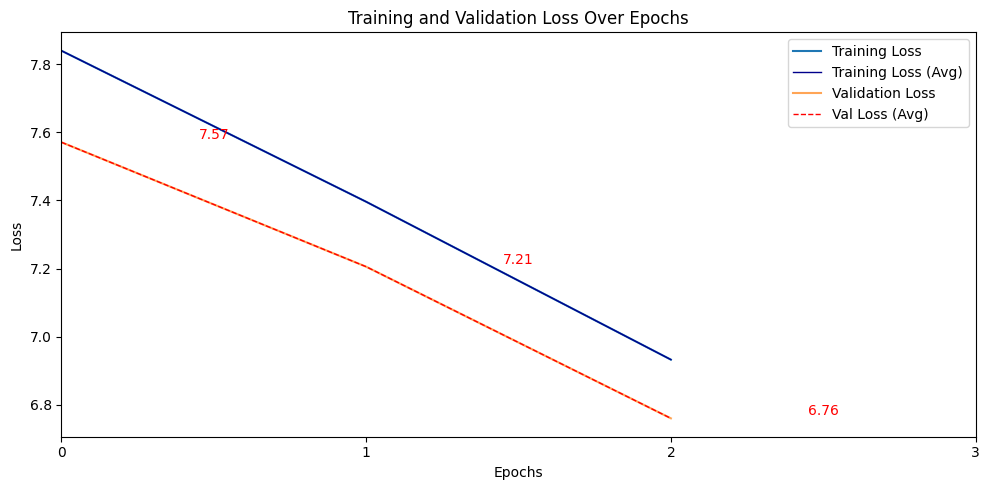

In [33]:
# Launch the training process
if __name__ == "__main__":
    print(f"Dataset found at {DATA_PATH} Initializing training...")
    tokenizer_src, tokenizer_tgt = load_tokenizers(data_path=DATA_PATH) 
    train_model(tokenizer_src, tokenizer_tgt)

# Inference

In [34]:
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    memory = model.encode(src, src_mask)
    # Use the batch size from the source
    batch_size = src.size(0)
    ys = torch.zeros(batch_size, 1).fill_(start_symbol).type_as(src.data)
    
    for i in range(max_len - 1):
        out = model.decode(
            memory, src_mask, ys, subsequent_mask(ys.size(1)).type_as(src.data)
        )
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        # next_word is (batch_size,) -> unsqueeze to (batch_size, 1) for concat
        ys = torch.cat(
            [ys, next_word.unsqueeze(1)], dim=1
        )
    return ys

In [35]:
def check_outputs(dataloader, model, tokenizer_src, tokenizer_tgt,
    n_examples=5, pad_idx=1, eos_string="</s>"):
    "Check the models outputs against the ground truth"

    results = [()] * n_examples
    valid_iter = iter(dataloader) 
    
    for idx in range(n_examples):
        print("\nExample %d ========\n" % idx)
        try:
            # Get the NEXT batch from the iterator
            b = next(valid_iter)
        except StopIteration:
            print('No more examples in test set.')
            break
            
        rb = Batch(b[0], b[1], pad_idx)
        
        src_text = tokenizer_src.decode(rb.src[0].tolist(), skip_special_tokens=True)
        tgt_text = tokenizer_tgt.decode(rb.tgt[0].tolist(), skip_special_tokens=True)

        print("Source Text (Input)        : " + src_text)
        print("Target Text (Ground Truth) : " + tgt_text)
        
        model_out = greedy_decode(model, rb.src, rb.src_mask, 72, 0)[0]
        model_txt = tokenizer_tgt.decode(model_out.tolist(), skip_special_tokens=True)
        
        print("Model Output               : " + model_txt)
        results[idx] = (rb, src_text, tgt_text, model_out, model_txt)
        
    return results

In [36]:
from torchmetrics.text import BLEUScore
from tqdm import tqdm

def calculate_bleu(model, dataloader, tokenizer_tgt, device=DEVICE):
    "Compute BLEU score, which measures n-gram overlaps"
    model.eval()
    metric = BLEUScore()
    
    preds, targets = [], []
    pad_idx = tokenizer_tgt.token_to_id("<pad>")
    start_symbol = tokenizer_tgt.token_to_id("<s>")
    
    with torch.no_grad():
        for b in tqdm(dataloader, desc="Computing BLEU"):
            src = b[0].to(device)  # b[0]: src, b[1]: tgt 
            src_mask = (src != pad_idx).unsqueeze(-2)
    
            model_out = greedy_decode(model, src, src_mask, max_len=72, start_symbol=start_symbol)
            preds.extend(tokenizer_tgt.decode_batch(model_out.cpu().tolist(), skip_special_tokens=True))     
            # Decode Ground Truth (b[1])
            ref_texts = tokenizer_tgt.decode_batch(b[1].tolist(), skip_special_tokens=True)
            targets.extend([[t] for t in ref_texts])

    score = metric(preds, targets)
    print(f"BLEU Score: {score.item():.4f}")

In [37]:
if __name__ == "__main__":
    
    tokenizer_src = Tokenizer.from_file("tokenizers/kaggletokenizer_src.json")
    tokenizer_tgt = Tokenizer.from_file("tokenizers/kaggletokenizer_tgt.json")
    model = make_model(tokenizer_src.get_vocab_size(), tokenizer_tgt.get_vocab_size(), N=6)
    checkpoint_path = "checkpoints/checkpoint_05.pt"
    print(f"Loading {checkpoint_path}...")

    # Load the saved weights to the model
    state_dict = torch.load(checkpoint_path, map_location=torch.device(DEVICE))
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()

    _, valid_dataloader = create_dataloaders(
        tokenizer_src,
        tokenizer_tgt,
        batch_size=32)

    check_outputs(valid_dataloader, model, tokenizer_src, tokenizer_tgt)
    calculate_bleu(model, valid_dataloader, tokenizer_tgt)

Exception: No such file or directory (os error 2)